# 4. Implementing Matrix Factorization


### (a) Image Reconstruction

## **Objective 1**  
Reconstruct an image with missing pixel values using **Gradient Descent**. Perform the following two cases:  
1. A rectangular block of size 30×30 is missing.  
2. A random subset of 900 (30×30) pixels is missing.  

Tasks:  
- Select an appropriate rank `r`.  
- Run Gradient Descent until convergence.  
- Plot:  
  - The selected missing regions,  
  - The original image,  
  - The reconstructed image.  
- Compute:  
  - **RMSE** (predicted vs ground truth),  
  - **Peak SNR**.  


Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torchvision

Device Set Up

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():  # For Mac GPUs
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Working on device:", device)

Working on device: cpu


Setting the Random Seed

Setting a random seed ensures reproducibility by making all random operations—like matrix initialization and pixel masking—produce the same results every time. This allows consistent, verifiable experiments

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

Loading the Image

Colored image shape (C,H,W): torch.Size([3, 337, 600])
Min pixel value: 0.0
Max pixel value: 1.0


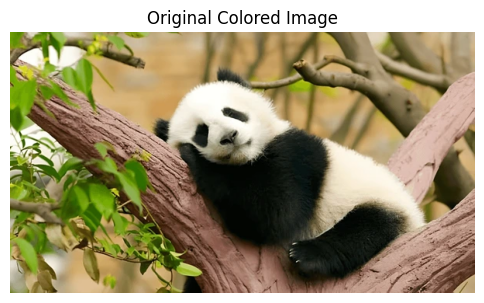

In [11]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0


color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\panda.jpg')  # shape: [C, H, W]
color_img = normalize_image(color_img)
print("Colored image shape (C,H,W):", color_img.shape)
print("Min pixel value:", color_img.min().item())
print("Max pixel value:", color_img.max().item())

# Display colored image
plt.figure(figsize=(6,6))
plt.imshow(color_img.permute(1,2,0))  # convert [C,H,W] -> [H,W,C] for matplotlib
plt.title("Original Colored Image")
plt.axis('off')
plt.show()

Converting to Grayscale

Grayscale image shape: torch.Size([337, 600])


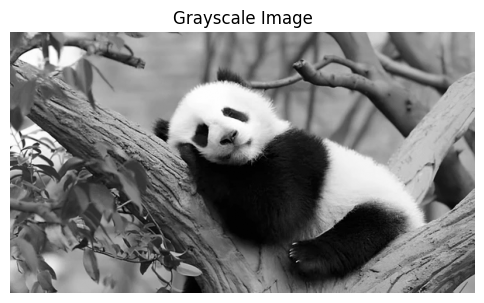

In [12]:
gray_img = color_img.mean(dim=0)  # average over channel dimension -> [H,W]
print("Grayscale image shape:", gray_img.shape)

plt.figure(figsize=(6,6))
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

# Convert to torch tensor for reconstruction
X = gray_img.clone()  # [H,W] tensor now it is ready for operations like matrix factorization

Move the Image tensor to device using .to(device) argument

In [13]:
X = X.to(device)

Defining Low Rank Reconstruction Function (Matrix Factorization)

In [29]:
def low_rank_reconstruction(X, mask, rank, lr, num_iters):
    """Function which does matrix factorization ; the arguments are:

    X = image tensor of the grayscale image [H,W]; it contains known pixel values
    mask = A tensor [H, W] with 1 for known pixels and 0 for missing pixels. This ensures we only calculate the loss on known pixels.
    r = The low-rank r of the factorization. X ≈ W @ H. Choosing r smaller than min(H, W) enforces a low-rank constraint that helps fill missing pixels using redundancy in the image.
    lr Learning rate for gradient descent. Controls how big each step is when updating W and H.
    Number of Iterations
    """
    
    m, n = X.shape
    W = torch.randn(m, rank, device=device, requires_grad=True)  #mXr matrix
    H = torch.randn(rank, n, device=device, requires_grad=True)  #rxm matrix
    ## W and H are randomly initialised and requires_grad = true calculates gradients with respect to these two


    optimizer = optim.Adam([W,H], lr=lr)

    ## iterative gradient descent step
    for it in range(num_iters):
        optimizer.zero_grad()
        X_hat = torch.mm(W,H)
        loss = ((X_hat - X) * mask).pow(2).sum()
        loss.backward()
        optimizer.step()
        
        if it % 500 == 0 or it == num_iters-1:
            print(f"Iteration {it}, Loss={loss.item():.6f}")
    
    return torch.mm(W,H).detach()


Metrics Calculation Function

In [46]:
def compute_metrics(X_true, X_pred):
    """Compute RMSE and PSNR over the entire image"""
    mse = ((X_true - X_pred).pow(2)).mean()
    rmse = torch.sqrt(mse).item()
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse)).item()
    return rmse, psnr

**case(i)**: Reconstructing the image for a rectangular block of 30X30 is assumed missing from the image.

Here, a mask is created to simulate missing pixels in the image. torch.ones_like(X) makes a mask of all ones (meaning all pixels are initially known). Then, a 30×30 block starting at (50,50) is set to zeros, marking those pixels as missing. Finally, multiplying X * block_mask sets the pixel values in that block to zero (hidden), while keeping the rest unchanged. This way, the algorithm knows which pixels are observed (1) and which are missing (0).

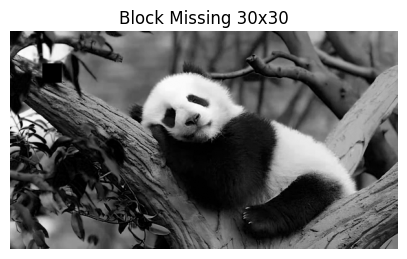

Iteration 0, Loss=12268322.000000
Iteration 500, Loss=7050.445312
Iteration 1000, Loss=4045.215088
Iteration 1500, Loss=2920.500488
Iteration 2000, Loss=2532.121582
Iteration 2500, Loss=2250.327637
Iteration 3000, Loss=1983.707642
Iteration 3500, Loss=1743.315430
Iteration 4000, Loss=1546.864014
Iteration 4500, Loss=1380.218018
Iteration 5000, Loss=1238.909180
Iteration 5500, Loss=1123.542847
Iteration 6000, Loss=1026.106567
Iteration 6500, Loss=938.365967
Iteration 7000, Loss=858.468689
Iteration 7500, Loss=786.747986
Iteration 8000, Loss=720.699158
Iteration 8500, Loss=663.474609
Iteration 9000, Loss=617.191589
Iteration 9500, Loss=575.236938
Iteration 9999, Loss=541.759033


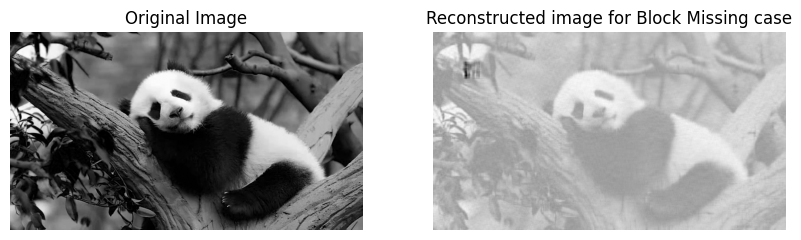

Block Missing: RMSE=0.067878, PSNR=23.37 dB


In [47]:
block_mask = torch.ones_like(X)
block_size = 30
start_row, start_col = 50, 50
block_mask[start_row:start_row+block_size, start_col:start_col+block_size] = 0
X_block_missing = X * block_mask

# Plot missing region
plt.figure(figsize=(5,5))
plt.imshow(X_block_missing.cpu(), cmap='gray')
plt.title("Block Missing 30x30")
plt.axis('off')
plt.show()

# Reconstruction
r = 60
X_block_rec = low_rank_reconstruction(X, block_mask, rank=r, lr=0.01, num_iters=10000)

# Plot original vs reconstructed
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(X.cpu(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(X_block_rec.cpu(), cmap='gray')
plt.title("Reconstructed image for Block Missing case")
plt.axis('off')
plt.show()

# Compute metrics
rmse_block, psnr_block = compute_metrics(X, X_block_rec)
print(f"Block Missing: RMSE={rmse_block:.6f}, PSNR={psnr_block:.2f} dB")

**case(ii)**: Reconstructing the image for a random subset of 900 (30X30) pixels is missing from the image.

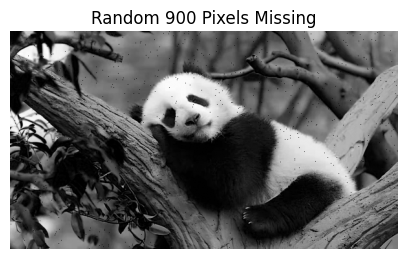

Iteration 0, Loss=11861704.000000
Iteration 500, Loss=7098.088379
Iteration 1000, Loss=4084.271240
Iteration 1500, Loss=3154.713867
Iteration 2000, Loss=2642.487549
Iteration 2500, Loss=2326.891846
Iteration 3000, Loss=2017.591187
Iteration 3500, Loss=1746.644287
Iteration 4000, Loss=1535.817139
Iteration 4500, Loss=1371.416016
Iteration 5000, Loss=1241.361084
Iteration 5500, Loss=1129.429688
Iteration 6000, Loss=1026.988159
Iteration 6500, Loss=933.731079
Iteration 7000, Loss=851.520264
Iteration 7500, Loss=778.277832
Iteration 8000, Loss=714.980957
Iteration 8500, Loss=661.032166
Iteration 9000, Loss=613.567871
Iteration 9500, Loss=573.621338
Iteration 9999, Loss=544.106689


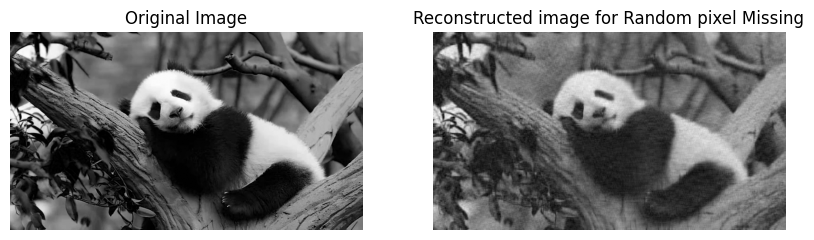

Random Missing: RMSE=0.052080, PSNR=25.67 dB


In [48]:
random_mask = torch.ones_like(X)
num_missing = 900
indices = torch.randperm(X.numel())[:num_missing]
random_mask.view(-1)[indices] = 0
X_random_missing = X * random_mask

# Plot missing region
plt.figure(figsize=(5,5))
plt.imshow(X_random_missing.cpu(), cmap='gray')
plt.title("Random 900 Pixels Missing")
plt.axis('off')
plt.show()

# Reconstruction
X_random_rec = low_rank_reconstruction(X, random_mask, rank=r, lr=0.01, num_iters=10000)

# Plot original vs reconstructed
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(X.cpu(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(X_random_rec.cpu(), cmap='gray')
plt.title("Reconstructed image for Random pixel Missing")
plt.axis('off')
plt.show()

# Compute metrics
rmse_random, psnr_random = compute_metrics(X, X_random_rec)
print(f"Random Missing: RMSE={rmse_random:.6f}, PSNR={psnr_random:.2f} dB")

Now as the factorization is done for Black and white which has 1 channel , we can extend the same algorithm to colored image , In the color image case, the input has three channels (R, G, B). Since our low-rank reconstruction method works on 2D matrices, we apply it independently to each channel. That means we treat the red, green, and blue layers as separate grayscale images, reconstruct the missing regions in each one using matrix factorization with gradient descent, and then stack the channels back together to form the final RGB image.

Loading the Image

In [35]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0

color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\panda.jpg') 
color_img = normalize_image(color_img).to(device)

print("Image shape:", color_img.shape)  

Image shape: torch.Size([3, 337, 600])


**case(i)**: Reconstructing the image for a rectangular block of 30X30 is assumed missing from the image.

Iteration 0, Loss=16214548.000000
Iteration 500, Loss=7118.420898
Iteration 1000, Loss=3728.991699
Iteration 1500, Loss=2825.325684
Iteration 2000, Loss=2406.461914
Iteration 2500, Loss=2122.682861
Iteration 3000, Loss=1875.423218
Iteration 3500, Loss=1649.768555
Iteration 4000, Loss=1456.647217
Iteration 4500, Loss=1296.774414
Iteration 5000, Loss=1160.606689
Iteration 5500, Loss=1041.511475
Iteration 6000, Loss=937.202759
Iteration 6500, Loss=844.242188
Iteration 7000, Loss=760.429749
Iteration 7500, Loss=686.093262
Iteration 8000, Loss=625.082397
Iteration 8500, Loss=570.015991
Iteration 9000, Loss=529.107544
Iteration 9500, Loss=494.310791
Iteration 9999, Loss=461.616394
Iteration 0, Loss=16013413.000000
Iteration 500, Loss=5676.773438
Iteration 1000, Loss=3320.205566
Iteration 1500, Loss=2574.923828
Iteration 2000, Loss=2185.009521
Iteration 2500, Loss=1897.695923
Iteration 3000, Loss=1673.513306
Iteration 3500, Loss=1498.708984
Iteration 4000, Loss=1357.278198
Iteration 4500, Los

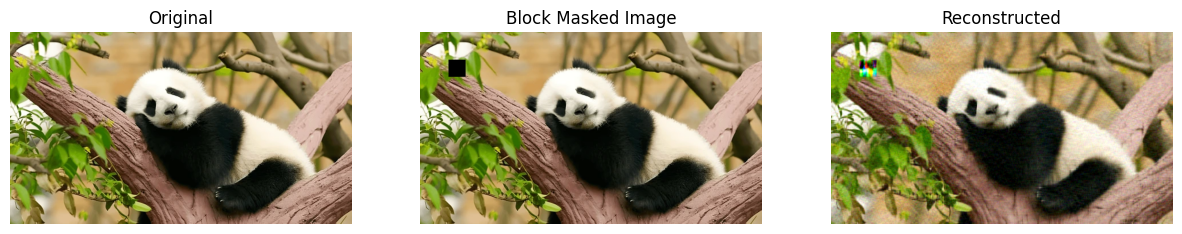

Block Missing: RMSE=0.060407, PSNR=24.38 dB


In [54]:
C, H, W = color_img.shape
block_mask = torch.ones((H, W), device=device)
block_size = 30
start_row, start_col = 50, 50
block_mask[start_row:start_row+block_size, start_col:start_col+block_size] = 0

rank = 80
color_block_missing = color_img * block_mask.unsqueeze(0)  # masked image
color_rec_block = []
for c in range(C):
    X = color_img[c]
    rec = low_rank_reconstruction(X, block_mask, rank=rank, lr=0.01, num_iters=10000)
    color_rec_block.append(rec)
color_rec_block = torch.stack(color_rec_block, dim=0)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(color_block_missing.permute(1,2,0).cpu())
plt.title("Block Masked Image")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(color_rec_block.permute(1,2,0).cpu().clamp(0,1))
plt.title("Reconstructed")
plt.axis('off')
plt.show()


rmse_block, psnr_block = compute_metrics(color_img, color_rec_block)
print(f"Block Missing: RMSE={rmse_block:.6f}, PSNR={psnr_block:.2f} dB")

**case(ii)**: Reconstructing the image for a random subset of 900 (30X30) pixels is missing from the image.

Iteration 0, Loss=10179779.000000
Iteration 500, Loss=7791.434570
Iteration 1000, Loss=4015.490723
Iteration 1500, Loss=3106.255615
Iteration 2000, Loss=2715.085449
Iteration 2500, Loss=2502.625977
Iteration 3000, Loss=2283.807373
Iteration 3500, Loss=2058.853027
Iteration 4000, Loss=1844.326294
Iteration 4500, Loss=1660.493896
Iteration 5000, Loss=1504.513428
Iteration 5500, Loss=1368.764771
Iteration 6000, Loss=1248.692749
Iteration 6500, Loss=1139.772827
Iteration 7000, Loss=1038.827271
Iteration 7500, Loss=948.808899
Iteration 8000, Loss=873.163269
Iteration 8500, Loss=805.102417
Iteration 9000, Loss=749.378174
Iteration 9500, Loss=700.857239
Iteration 9999, Loss=661.711731
Iteration 0, Loss=10301559.000000
Iteration 500, Loss=7074.865234
Iteration 1000, Loss=3908.758301
Iteration 1500, Loss=3039.170654
Iteration 2000, Loss=2585.041992
Iteration 2500, Loss=2224.530029
Iteration 3000, Loss=1998.868164
Iteration 3500, Loss=1816.171021
Iteration 4000, Loss=1651.244019
Iteration 4500, 

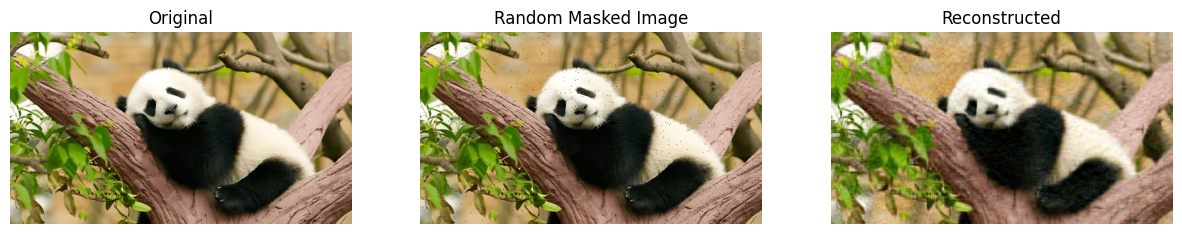

Random Missing: RMSE=0.056346, PSNR=24.98 dB


In [53]:
random_mask = torch.ones((H, W), device=device)
num_missing = 900
indices = torch.randperm(H*W, device=device)[:num_missing]
random_mask.view(-1)[indices] = 0
rank = 50
color_random_missing = color_img * random_mask.unsqueeze(0)  # masked image
color_rec_random = []
for c in range(C):
    X = color_img[c]
    rec = low_rank_reconstruction(X, random_mask, rank=rank, lr=0.01, num_iters=10000)
    color_rec_random.append(rec)
color_rec_random = torch.stack(color_rec_random, dim=0)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(color_random_missing.permute(1,2,0).cpu())
plt.title("Random Masked Image")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(color_rec_random.permute(1,2,0).cpu().clamp(0,1))
plt.title("Reconstructed")
plt.axis('off')
plt.show()

rmse_random, psnr_random = compute_metrics(color_img, color_rec_random)
print(f"Random Missing: RMSE={rmse_random:.6f}, PSNR={psnr_random:.2f} dB")


In low-rank matrix reconstruction, the rank 
r determines the expressive capacity of the factorization 
𝑋≈𝑊⋅𝐻
X≈W⋅H. A smaller rank enforces a simpler model, which can capture only the most dominant patterns in the image but fails to recover fine details, especially in large missing regions such as a 30×30 block. This often results in blurry or inaccurate reconstructions. Increasing the rank allows the model to represent more complex structures and textures, improving the reconstruction quality of missing pixels. However, a very high rank can lead to overfitting and increased computational cost. In practice, the rank is chosen as a trade-off: moderate values are sufficient for randomly missing pixels, while larger ranks are beneficial for reconstructing contiguous missing blocks where local information is unavailable. Adjusting the rank alongside the number of iterations and learning rate allows the gradient descent optimization to better approximate the high-resolution image.

## **Objective 2**  
Reconstruct the same images (Case 1 and 2) using **Alternating Least Squares (ALS)** instead of Gradient Descent.  

Tasks:  
- Write your own ALS function using [`torch.linalg.lstsq`](https://pytorch.org/docs/stable/generated/torch.linalg.lstsq.html).  
- Compare reconstructed results and metrics with the Gradient Descent approach.  


Loading the Image

In [55]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0

color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\panda.jpg') 
color_img = normalize_image(color_img).to(device)

print("Image shape:", color_img.shape)  

Image shape: torch.Size([3, 337, 600])


Defining the Low rank Reconstruction Fuction using ALS Method

In [ ]:
def low_rank_reconstruction_als(X, mask, rank, num_iters):
    """
    X     : [H,W] grayscale image (or one channel of colored image)
    mask  : [H,W] binary tensor: 1 for known pixels, 0 for missing
    rank  : rank for low-rank factorization
    num_iters : number of ALS iterations
    """
    m, n = X.shape
    device = X.device
    
    # Random initialization
    W = torch.randn(m, rank, device=device)
    H = torch.randn(rank, n, device=device)
    
    mask = mask.to(dtype=X.dtype)
    
    for it in range(num_iters):
        
        for i in range(m):
            known_idx = mask[i, :] == 1
            if known_idx.sum() == 0:
                continue
            H_sub = H[:, known_idx]
            X_sub = X[i, known_idx]
            w_i, _ = torch.linalg.lstsq(H_sub.T, X_sub.T)[:2]
            W[i, :] = w_i.T
        
        
        for j in range(n):
            known_idx = mask[:, j] == 1
            if known_idx.sum() == 0:
                continue
            W_sub = W[known_idx, :]
            X_sub = X[known_idx, j]
            h_j, _ = torch.linalg.lstsq(W_sub, X_sub)[:2]
            H[:, j] = h_j.squeeze()
    
    return torch.mm(W, H)

**case(i)**: Reconstructing the image for a rectangular block of 30X30 is assumed missing from the image.

C:\Users\Parth Dembla\AppData\Local\Temp\ipykernel_14688\3636762258.py:25: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4424.)
  w_i, _ = torch.linalg.lstsq(H_sub.T, X_sub.T)[:2]


Block Missing: RMSE=0.099023, PSNR=20.09 dB


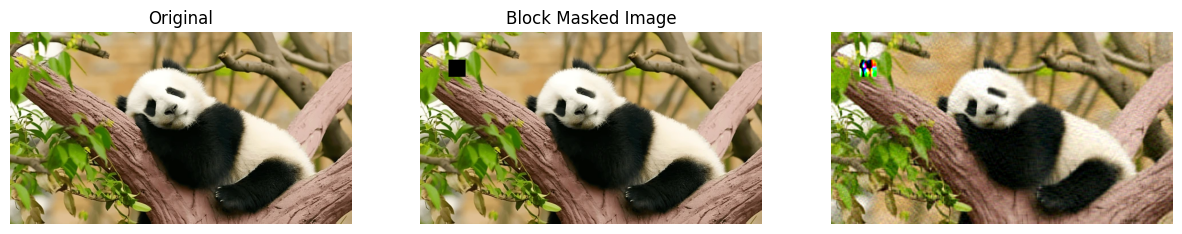

In [57]:
block_mask = torch.ones((H, W), device=device)
block_size = 30
block_mask[50:50+block_size, 50:50+block_size] = 0

color_block_missing = color_img * block_mask.unsqueeze(0)

# ALS reconstruction for each channel
rank = 50
color_rec_block_als = []
for c in range(C):
    X = color_img[c]
    rec = low_rank_reconstruction_als(X, block_mask, rank=rank, num_iters=30)
    color_rec_block_als.append(rec)
color_rec_block_als = torch.stack(color_rec_block_als, dim=0)

rmse_block_als, psnr_block_als = compute_metrics(color_img, color_rec_block_als)
print(f"Block Missing: RMSE={rmse_block_als:.6f}, PSNR={psnr_block_als:.2f} dB")


plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(color_block_missing.permute(1,2,0).cpu())
plt.title("Block Masked Image")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(color_rec_block_als.permute(1,2,0).cpu().clamp(0,1))
plt.axis('off')
plt.show()

**case(ii)**: Reconstructing the image for a random subset of 900 (30X30) pixels is missing from the image.

Random Missing: RMSE=0.046427, PSNR=26.66 dB


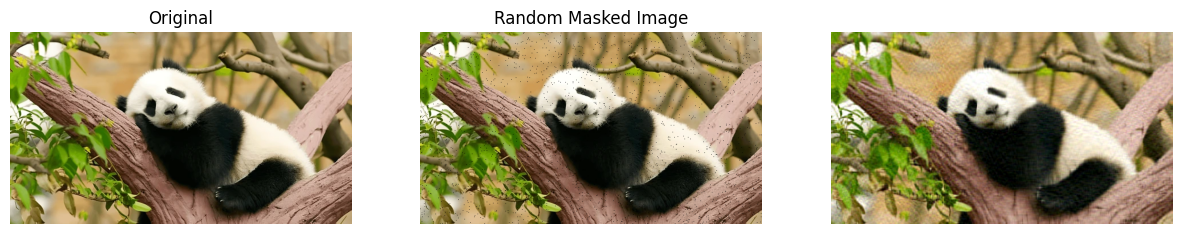

In [58]:
random_mask = torch.ones((H, W), device=device)
num_missing = 2000
indices = torch.randperm(H*W, device=device)[:num_missing]
random_mask.view(-1)[indices] = 0

color_random_missing = color_img * random_mask.unsqueeze(0)

# ALS reconstruction for each channel
color_rec_random_als = []
for c in range(C):
    X = color_img[c]
    rec = low_rank_reconstruction_als(X, random_mask, rank=rank, num_iters=30)
    color_rec_random_als.append(rec)
color_rec_random_als = torch.stack(color_rec_random_als, dim=0)

rmse_random_als, psnr_random_als = compute_metrics(color_img, color_rec_random_als)

print(f"Random Missing: RMSE={rmse_random_als:.6f}, PSNR={psnr_random_als:.2f} dB")


plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(color_random_missing.permute(1,2,0).cpu())
plt.title("Random Masked Image")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(color_rec_random_als.permute(1,2,0).cpu().clamp(0,1))

plt.axis('off')
plt.show()


**Comparing the ALS and Gradient Descent Results**